# Proyecto Final: Transformación y Modelado de Indicadores Socioeconómicos en Latinoamérica

**Curso:** CC3074 - Minería de Datos  
**Framework:** CRISP-DM - Fase 3: Preparación de Datos  
**Fuente de datos:** CEPALSTAT - Observatorio de Desarrollo Digital (ODD)  
**Indicador:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe  

**Integrantes:** 
 
- Cristian Túnchez (231359)  
- Dulce Ambrosio (231143)  
- Daniel Chet (231177)  
- Javier Linares (231135)  

## Semana 2 - Transformación del Conjunto de Datos: Construcción del Conjunto Analítico

---
### Contexto y Objetivo

En la Semana 1 se realizó el Análisis Exploratorio de Datos (EDA) sobre los **870 registros × 8 columnas** publicados por CEPAL. Se identificaron los siguientes hallazgos críticos para la fase de preparación de datos:

- **Cuatro columnas no informativas:** `indicator`, `unit`, `source_id` (constantes) y `notes_ids` (100% nula).
- **Panel desbalanceado:** sólo el **49.3%** de las combinaciones país × año × grupo etario están reportadas (870 de 1,764 posibles; 145 de 294 pares país-año).
- **Formato largo (long/tidy):** una única columna numérica `value` con dimensión categórica `Grupos etarios Uso Internet`, lo que dificulta el análisis multivariado.
- **Tipos de datos heterogéneos:** nombres de columnas con caracteres especiales y dobles guiones bajos.

**Objetivo de la Semana 2:** ejecutar la **Fase 3 completa de CRISP-DM (Preparación de Datos)**, dejando el conjunto de datos listo para la Fase de Modelado en la Semana 3.

**Configuración del entorno e importación de librerías**

In [86]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Paleta personalizada para grupos etarios (de joven a mayor)
PALETA_EDAD = {
    'edad de medicion a 17 años': '#2196F3',
    '18 a 25 años de edad': '#4CAF50',
    '26 a 50 años de edad': '#FF9800',
    '51 a 65 años': '#F44336',
    '66 años en adelante': '#9C27B0',
    'Total': '#607D8B'
}

ORDEN_EDAD = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante',
    'Total'
]

# Etiquetas cortas para gráficos
ETIQUETAS_CORTAS = {
    'edad de medicion a 17 años': '<=17 años',
    '18 a 25 años de edad': '18-25',
    '26 a 50 años de edad': '26-50',
    '51 a 65 años': '51-65',
    '66 años en adelante': '66+',
    'Total': 'Total'
}

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.0
numpy: 2.4.2


**Carga de datos desde el archivo Excel (hoja `datos`)**

In [87]:
df = pd.read_excel('data.xlsx', sheet_name='datos')

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nColumnas originales:')
for c in df.columns:
    print(f'  - {c}')
print(f'\nPrimeras filas:')
display(df.head())

Dataset cargado: 870 filas x 8 columnas

Columnas originales:
  - indicator
  - País__ESTANDAR
  - Grupos etarios Uso Internet
  - Años__ESTANDAR
  - value
  - unit
  - notes_ids
  - source_id

Primeras filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2016,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
1,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2017,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
2,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2018,78.5,Porcentaje sobre el total de personas en cada ...,NaN,9353
3,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2019,78.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
4,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2020,87.5,Porcentaje sobre el total de personas en cada ...,NaN,9353


**Recapitulación del estado inicial**

In [88]:
print('=' * 70)
print('ESTADO INICIAL DEL DATASET')
print('=' * 70)
print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nValores únicos por columna:')
print('─' * 50)
for col in df.columns:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    print(f'  {col:35s}  únicos: {n_unique:4d}  nulos: {n_null:4d}')

print(f'\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

ESTADO INICIAL DEL DATASET

Dimensiones: 870 filas x 8 columnas

Valores únicos por columna:
──────────────────────────────────────────────────
  indicator                            únicos:    1  nulos:    0
  País__ESTANDAR                       únicos:   14  nulos:    0
  Grupos etarios Uso Internet          únicos:    6  nulos:    0
  Años__ESTANDAR                       únicos:   21  nulos:    0
  value                                únicos:  577  nulos:    0
  unit                                 únicos:    1  nulos:    0
  notes_ids                            únicos:    0  nulos:  870
  source_id                            únicos:    1  nulos:    0

Memoria utilizada: 495.7 KB


---
### 1. Limpieza Preliminar

Antes de pivotear, eliminamos las columnas no informativas identificadas en la Semana 1 y normalizamos los nombres de las columnas restantes a un esquema en español, en minúsculas y sin caracteres problemáticos para CSV.

**Eliminación de columnas constantes y nulas**

In [89]:
COLUMNAS_NO_INFORMATIVAS = ['indicator', 'unit', 'source_id', 'notes_ids']

print('Columnas a eliminar y razón:')
print('─' * 50)
for col in COLUMNAS_NO_INFORMATIVAS:
    n_unique = df[col].nunique(dropna=False)
    n_null = df[col].isna().sum()
    if n_null == len(df):
        razon = '100% nula'
    elif n_unique == 1:
        razon = f'constante (valor único)'
    else:
        razon = '?'
    print(f'  {col:15s}  →  {razon}')

df = df.drop(columns=COLUMNAS_NO_INFORMATIVAS)
print(f'\nForma tras eliminar columnas: {df.shape}')

Columnas a eliminar y razón:
──────────────────────────────────────────────────
  indicator        →  constante (valor único)
  unit             →  constante (valor único)
  source_id        →  constante (valor único)
  notes_ids        →  100% nula

Forma tras eliminar columnas: (870, 4)


**Renombrado de columnas a snake_case en español**

In [90]:
MAPEO_COLUMNAS = {
    'País__ESTANDAR': 'pais',
    'Grupos etarios Uso Internet': 'grupo_etario',
    'Años__ESTANDAR': 'año',
    'value': 'valor'
}

print('Mapeo de renombramiento:')
print('─' * 50)
for original, nuevo in MAPEO_COLUMNAS.items():
    print(f'  {original:35s}  →  {nuevo}')

df = df.rename(columns=MAPEO_COLUMNAS)
df['año'] = df['año'].astype(int)

print(f'\nTipos de datos tras limpieza:')
print(df.dtypes)
print(f'\nMuestra:')
display(df.head())

Mapeo de renombramiento:
──────────────────────────────────────────────────
  País__ESTANDAR                       →  pais
  Grupos etarios Uso Internet          →  grupo_etario
  Años__ESTANDAR                       →  año
  value                                →  valor

Tipos de datos tras limpieza:
pais                str
grupo_etario        str
año               int64
valor           float64
dtype: object

Muestra:


,pais,grupo_etario,año,valor
0,Argentina,edad de medicion a 17 años,2016,75.9
1,Argentina,edad de medicion a 17 años,2017,75.9
2,Argentina,edad de medicion a 17 años,2018,78.5
3,Argentina,edad de medicion a 17 años,2019,78.9
4,Argentina,edad de medicion a 17 años,2020,87.5


**Justificación de las decisiones de limpieza**

| Columna eliminada | Razón |
|---|---|
| `indicator` | Constante: contiene el mismo nombre del indicador en todas las filas. |
| `unit` | Constante: todas las observaciones están en "Porcentaje sobre el total de personas en cada grupo etario". |
| `source_id` | Constante: todas las filas referencian la misma fuente (ID 9353). |
| `notes_ids` | 100% nula: ninguna observación tiene notas asociadas. |

| Columna renombrada | Motivo |
|---|---|
| `País__ESTANDAR` → `pais` | Eliminar doble guión bajo y mayúsculas; estandarizar a snake_case. |
| `Grupos etarios Uso Internet` → `grupo_etario` | Eliminar espacios; nombre más conciso y compatible con CSV/SQL. |
| `Años__ESTANDAR` → `año` | Eliminar doble guión bajo; nombre semántico. |
| `value` → `valor` | Coherencia con resto de columnas en español. |

---
### 2. Pivoteo de Datos: de Formato Largo a Ancho

El dataset original está en **formato largo (long/tidy)**: cada fila es una observación (`pais`, `grupo_etario`, `año`) con un único valor numérico. Para análisis multivariado, modelado y visualización es preferible un **formato ancho (wide)** donde cada fila representa una unidad de observación (par `pais`-`año`) y cada columna representa un indicador (un grupo etario).

Este pivoteo convierte un único indicador con dimensión categórica en **6 indicadores numéricos** independientes, listos para análisis correlacional, clustering y modelado supervisado en fases posteriores.

**Pivote: index=(pais, año), columns=grupo_etario, values=valor**

In [91]:
df_wide = df.pivot_table(
    index=['pais', 'año'],
    columns='grupo_etario',
    values='valor',
    aggfunc='first'
).reset_index()
df_wide.columns.name = None

# Reordenar columnas siguiendo la progresión etaria definida en ORDEN_EDAD
df_wide = df_wide[['pais', 'año'] + ORDEN_EDAD]

print(f'Forma tras el pivoteo: {df_wide.shape}')
print(f'\nCombinaciones (pais, año) observadas: {df_wide.shape[0]}')
print(f'Indicadores generados (columnas de grupo etario): {len(ORDEN_EDAD)}')
print(f'\nColumnas resultantes:')
for c in df_wide.columns:
    print(f'  - {c}')
print(f'\nMuestra del DataFrame pivoteado:')
display(df_wide.head(10))

Forma tras el pivoteo: (145, 8)

Combinaciones (pais, año) observadas: 145
Indicadores generados (columnas de grupo etario): 6

Columnas resultantes:
  - pais
  - año
  - edad de medicion a 17 años
  - 18 a 25 años de edad
  - 26 a 50 años de edad
  - 51 a 65 años
  - 66 años en adelante
  - Total

Muestra del DataFrame pivoteado:


,pais,año,edad de medicion a 17 años,18 a 25 años de edad,26 a 50 años de edad,51 a 65 años,66 años en adelante,Total
0,Argentina,2016,75.9,86.4,82.0,60.9,28.6,71.1
1,Argentina,2017,75.9,89.7,85.6,67.6,34.0,74.4
2,Argentina,2018,78.5,90.2,88.1,73.8,39.7,77.7
3,Argentina,2019,78.9,92.0,89.6,77.3,46.1,80.0
4,Argentina,2020,87.5,95.0,91.9,80.6,54.5,85.6
5,Argentina,2021,86.9,94.9,94.2,86.9,57.4,87.2
6,Argentina,2022,86.5,96.8,95.2,88.4,62.7,88.5
7,Bolivia (Estado Plurinacional de),2009,30.2,56.1,26.8,11.1,2.5,29.5
8,Bolivia (Estado Plurinacional de),2012,39.1,62.4,33.1,14.8,3.7,35.5
9,Bolivia (Estado Plurinacional de),2013,38.9,66.6,36.8,17.6,5.2,37.1


**Verificación: ausencia de duplicados y consistencia del pivote**

In [92]:
print('=' * 70)
print('VALIDACIÓN DEL PIVOTE')
print('=' * 70)

# Verificar que no hubo agregación silenciosa
duplicados = df.duplicated(subset=['pais', 'año', 'grupo_etario']).sum()
print(f'\nDuplicados en (pais, año, grupo_etario) en formato largo: {duplicados}')

# Reconstrucción de control: filas largas vs (filas wide × 6 grupos)
esperado = len(df_wide) * len(ORDEN_EDAD)
print(f'\nObservaciones largas: {len(df)}')
print(f'Filas wide × 6 grupos:  {esperado}')
print(f'¿Coinciden?            {len(df) == esperado}')

# Verificar conteo de NaN dentro del pivote (no deberían existir si los grupos están balanceados)
print(f'\nNaN por columna en el DataFrame pivoteado:')
print('─' * 50)
print(df_wide.isna().sum().to_string())

VALIDACIÓN DEL PIVOTE

Duplicados en (pais, año, grupo_etario) en formato largo: 0

Observaciones largas: 870
Filas wide × 6 grupos:  870
¿Coinciden?            True

NaN por columna en el DataFrame pivoteado:
──────────────────────────────────────────────────
pais                          0
año                           0
edad de medicion a 17 años    0
18 a 25 años de edad          0
26 a 50 años de edad          0
51 a 65 años                  0
66 años en adelante           0
Total                         0


**Interpretación**: cada par (pais, año), reportado en la fuente, contiene los 6 grupos etarios completos (panel balanceado condicional a observación). Por eso el pivote no introduce NaN dentro de las filas. Los faltantes reales están a nivel de panel: pares (pais, año) ausentes en la fuente, no celdas vacías.

---
### 3. Manejo de Múltiples Indicadores

Tras el pivoteo, las 6 categorías de `grupo_etario` se convierten en **6 columnas-indicador** independientes. En esta sección las renombramos a identificadores limpios (snake_case, ordenados por edad ascendente) y documentamos por qué se conserva `Total` como un indicador separado y no se recalcula a partir de los demás.

**Renombrado de los 6 indicadores y reordenamiento por progresión etaria**

In [93]:
MAPEO_INDICADORES = {
    'edad de medicion a 17 años': 'pct_uso_<=17',
    '18 a 25 años de edad':        'pct_uso_18_25',
    '26 a 50 años de edad':        'pct_uso_26_50',
    '51 a 65 años':                'pct_uso_51_65',
    '66 años en adelante':         'pct_uso_66_mas',
    'Total':                       'pct_uso_total'
}

df_wide = df_wide.rename(columns=MAPEO_INDICADORES)

INDICADORES = [
    'pct_uso_<=17',
    'pct_uso_18_25',
    'pct_uso_26_50',
    'pct_uso_51_65',
    'pct_uso_66_mas',
    'pct_uso_total'
]
ORDEN_COLUMNAS = ['pais', 'año'] + INDICADORES
df_wide = df_wide[ORDEN_COLUMNAS]

print('Mapeo de indicadores aplicado:')
print('─' * 70)
for original, nuevo in MAPEO_INDICADORES.items():
    print(f'  {original:35s}  →  {nuevo}')

print(f'\nDataFrame con indicadores renombrados:')
display(df_wide.head(10))

Mapeo de indicadores aplicado:
──────────────────────────────────────────────────────────────────────
  edad de medicion a 17 años           →  pct_uso_<=17
  18 a 25 años de edad                 →  pct_uso_18_25
  26 a 50 años de edad                 →  pct_uso_26_50
  51 a 65 años                         →  pct_uso_51_65
  66 años en adelante                  →  pct_uso_66_mas
  Total                                →  pct_uso_total

DataFrame con indicadores renombrados:


,pais,año,pct_uso_<=17,pct_uso_18_25,pct_uso_26_50,pct_uso_51_65,pct_uso_66_mas,pct_uso_total
0,Argentina,2016,75.9,86.4,82.0,60.9,28.6,71.1
1,Argentina,2017,75.9,89.7,85.6,67.6,34.0,74.4
2,Argentina,2018,78.5,90.2,88.1,73.8,39.7,77.7
3,Argentina,2019,78.9,92.0,89.6,77.3,46.1,80.0
4,Argentina,2020,87.5,95.0,91.9,80.6,54.5,85.6
5,Argentina,2021,86.9,94.9,94.2,86.9,57.4,87.2
6,Argentina,2022,86.5,96.8,95.2,88.4,62.7,88.5
7,Bolivia (Estado Plurinacional de),2009,30.2,56.1,26.8,11.1,2.5,29.5
8,Bolivia (Estado Plurinacional de),2012,39.1,62.4,33.1,14.8,3.7,35.5
9,Bolivia (Estado Plurinacional de),2013,38.9,66.6,36.8,17.6,5.2,37.1


**Decisión documentada: conservación de `pct_uso_total` como indicador independiente**

Aunque `pct_uso_total` podría parecer derivable como un promedio ponderado de los grupos etarios desagregados, **se conserva como un indicador separado** por las siguientes razones:

1. **CEPAL lo reporta como medición independiente:** la fuente lo calcula directamente sobre el total poblacional, no como agregación de los subgrupos.
2. **Ausencia de pesos demográficos:** el dataset no incluye la distribución poblacional por grupo etario en cada país-año, por lo que un promedio ponderado correcto no es reproducible con la información disponible.
3. **Valor analítico:** mantener `pct_uso_total` como indicador agregado permite (a) comparar adopción digital total entre países, (b) usarlo como variable objetivo en modelos predictivos posteriores, y (c) detectar inconsistencias entre la medición agregada y la desagregada.

Por lo anterior, en la fase de imputación de la Sección 4 **se aplicará la misma estrategia a los 6 indicadores por igual**, sin reconstruir `pct_uso_total` a partir de los demás.

---
### 4. Manejo de Valores Faltantes

El concepto de "valor faltante" en este dataset opera a **nivel de panel**: no todos los pares `(pais, año)` existen en la fuente. Como se identificó en la Semana 1, la cobertura es del **49.3%** considerando los 6 grupos etarios (870 de 1,764 combinaciones), o equivalentemente **145 de 294 pares país-año** posibles.

Esta sección procede en cinco subetapas:

1. Diagnóstico inicial de la estructura del panel.
2. Completado del grid cartesiano (introduciendo NaN explícitos).
3. Comparación de estrategias de manejo de valores faltantes.
4. Aplicación de la estrategia adoptada (interpolación lineal intra-país).
5. Diagnóstico final y documentación de NaN residuales.

#### 4.1 Diagnóstico Inicial: Estructura del Panel

**Mapa de calor: pares (pais, año) presentes en la fuente**

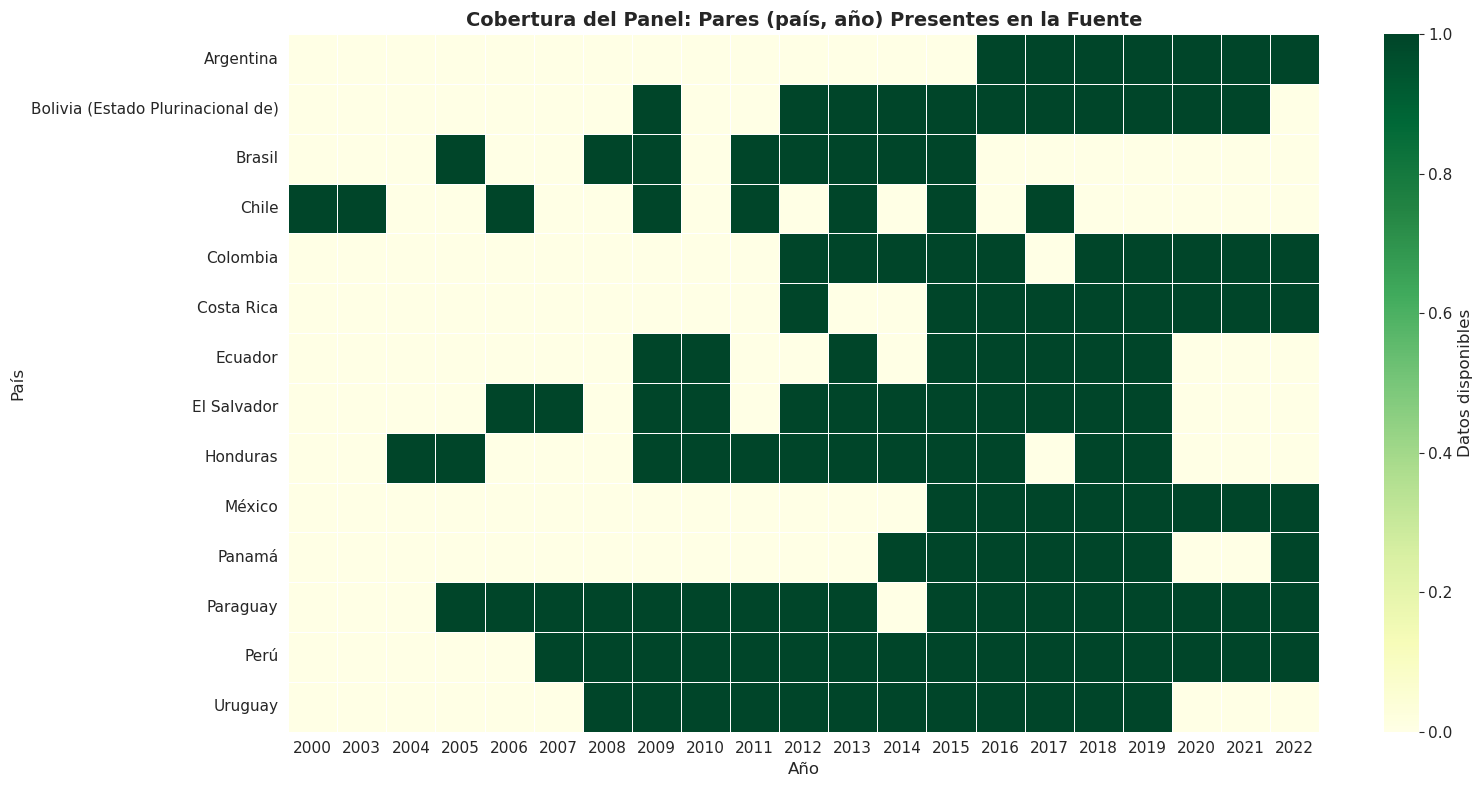

RESUMEN DEL PANEL
  Países:                        14
  Rango temporal:                2000–2022 (23 años)
  Pares (país, año) esperados:   322
  Pares (país, año) observados:  145
  Pares faltantes:               177  (55.0%)


In [94]:
presencia = (df_wide.assign(presente=1)
                    .pivot_table(index='pais', columns='año', values='presente', aggfunc='first')
                    .fillna(0)
                    .astype(int))

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(presencia, cmap='YlGn', cbar_kws={'label': 'Datos disponibles'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Cobertura del Panel: Pares (país, año) Presentes en la Fuente',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('País')
plt.tight_layout()
plt.show()

n_paises = df_wide['pais'].nunique()
rango_años = (int(df_wide['año'].min()), int(df_wide['año'].max()))
n_años = rango_años[1] - rango_años[0] + 1
esperado_pares = n_paises * n_años
observado_pares = len(df_wide)
faltantes = esperado_pares - observado_pares

print('=' * 70)
print('RESUMEN DEL PANEL')
print('=' * 70)
print(f'  Países:                        {n_paises}')
print(f'  Rango temporal:                {rango_años[0]}–{rango_años[1]} ({n_años} años)')
print(f'  Pares (país, año) esperados:   {esperado_pares}')
print(f'  Pares (país, año) observados:  {observado_pares}')
print(f'  Pares faltantes:               {faltantes}  ({faltantes/esperado_pares*100:.1f}%)')

#### 4.2 Completado del Grid Cartesiano

**Reindexar a todas las combinaciones (país × año) y exponer NaN**

In [95]:
paises = sorted(df_wide['pais'].unique())
años = list(range(rango_años[0], rango_años[1] + 1))

idx_completo = pd.MultiIndex.from_product([paises, años], names=['pais', 'año'])
df_grid = (df_wide.set_index(['pais', 'año'])
                  .reindex(idx_completo)
                  .reset_index())

print(f'Forma tras completar el grid: {df_grid.shape}')
filas_todo_nan = df_grid[INDICADORES].isna().all(axis=1).sum()
print(f'\nFilas con TODOS los indicadores NaN (pares no reportados): {filas_todo_nan}')
print(f'Filas con al menos un valor reportado:                    {len(df_grid) - filas_todo_nan}')

print(f'\nNulos por columna tras reindex:')
print('─' * 50)
print(df_grid.isna().sum().to_string())

print(f'\nMuestra (incluye filas totalmente NaN, p. ej. años sin observar):')
display(df_grid.head(15))

Forma tras completar el grid: (322, 8)

Filas con TODOS los indicadores NaN (pares no reportados): 177
Filas con al menos un valor reportado:                    145

Nulos por columna tras reindex:
──────────────────────────────────────────────────
pais                0
año                 0
pct_uso_<=17      177
pct_uso_18_25     177
pct_uso_26_50     177
pct_uso_51_65     177
pct_uso_66_mas    177
pct_uso_total     177

Muestra (incluye filas totalmente NaN, p. ej. años sin observar):


,pais,año,pct_uso_<=17,pct_uso_18_25,pct_uso_26_50,pct_uso_51_65,pct_uso_66_mas,pct_uso_total
0,Argentina,2000,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,2001,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,2002,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,2003,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,2004,NaN,NaN,NaN,NaN,NaN,NaN
5,Argentina,2005,NaN,NaN,NaN,NaN,NaN,NaN
6,Argentina,2006,NaN,NaN,NaN,NaN,NaN,NaN
7,Argentina,2007,NaN,NaN,NaN,NaN,NaN,NaN
8,Argentina,2008,NaN,NaN,NaN,NaN,NaN,NaN
9,Argentina,2009,NaN,NaN,NaN,NaN,NaN,NaN


#### 4.3 Estrategias Consideradas

| # | Estrategia | Acción | Ventaja | Desventaja | Decisión |
|---|---|---|---|---|---|
| A | **Sparse** | Mantener únicamente las 145 filas observadas en la fuente. | No introduce supuestos sobre datos no observados. | Series temporales con cortes; dificulta análisis de tendencias y modelos secuenciales. | Descartada |
| B | **Interpolación lineal intra-país** | Completar el grid (294 filas) e interpolar entre años observados de cada país, sin extrapolar fuera del rango. | Conserva continuidad temporal sin inventar datos en extremos. Asume linealidad sólo localmente. | Asume linealidad entre observaciones consecutivas. | **Adoptada** |
| C | **Drop con cualquier NaN** | Eliminar todo (país, año) con al menos un grupo etario ausente. | Datos 100% reportados. | Pérdida masiva (>50%); sesgo hacia países con cobertura completa. | Descartada |

**Justificación de la elección (B):**

1. La adopción de Internet sigue trayectorias **país-específicas**, por lo que interpolar entre países (cross-section) introduciría sesgo. Interpolar dentro de cada país (intra-país, time-series) es metodológicamente correcto.
2. La opción `limit_area='inside'` de `pandas.DataFrame.interpolate` **garantiza no extrapolar** antes del primer valor observado ni después del último — evitando producir porcentajes negativos o mayores a 100% en extremos.
3. Permite mantener la estructura de panel completa (`294 filas × 8 columnas`) facilitando análisis posteriores, mientras documenta los residuos imposibles de imputar.

#### 4.4 Aplicación: Interpolación Lineal Intra-País

**Imputación con `interpolate(method='linear', limit_area='inside')` por país**

In [96]:
# Interpolación lineal intra-país sobre los 6 indicadores.
# Se usa groupby.transform en lugar de groupby.apply porque transform garantiza
# que el frame de salida conserva la misma forma, índice y columnas que la entrada
# (incluyendo la columna `pais`). El comportamiento de `apply` sobre la columna
# de grupo cambió entre pandas 2.x y 3.x, lo que hacía frágil cualquier patrón
# basado en apply + reset_index. transform es version-agnostic.

df_interp = df_grid.sort_values(['pais', 'año']).copy()
df_interp[INDICADORES] = (
    df_interp.groupby('pais')[INDICADORES]
             .transform(lambda s: s.interpolate(method='linear', limit_area='inside'))
)

print('Interpolación aplicada por país.')
print(f'\nNulos por columna después de interpolación:')
print('─' * 50)
print(df_interp.isna().sum().to_string())

# Eliminar filas que quedaron 100% NaN (años fuera del rango observado del país)
mascara_todos_nan = df_interp[INDICADORES].isna().all(axis=1)
n_drop = int(mascara_todos_nan.sum())
df_interp = df_interp.loc[~mascara_todos_nan].reset_index(drop=True)

print(f'\nFilas eliminadas (todos los indicadores aún NaN tras interpolación): {n_drop}')
print(f'  Razón: corresponden a años fuera del rango temporal observado de cada país,')
print(f'         donde la opción limit_area="inside" intencionalmente NO extrapola.')

print(f'\nForma tras interpolación + drop: {df_interp.shape}')


Interpolación aplicada por país.

Nulos por columna después de interpolación:
──────────────────────────────────────────────────
pais                0
año                 0
pct_uso_<=17      147
pct_uso_18_25     147
pct_uso_26_50     147
pct_uso_51_65     147
pct_uso_66_mas    147
pct_uso_total     147

Filas eliminadas (todos los indicadores aún NaN tras interpolación): 147
  Razón: corresponden a años fuera del rango temporal observado de cada país,
         donde la opción limit_area="inside" intencionalmente NO extrapola.

Forma tras interpolación + drop: (175, 8)


#### 4.5 Diagnóstico Final

**Mapa de calor post-imputación y conteo de NaN residuales**

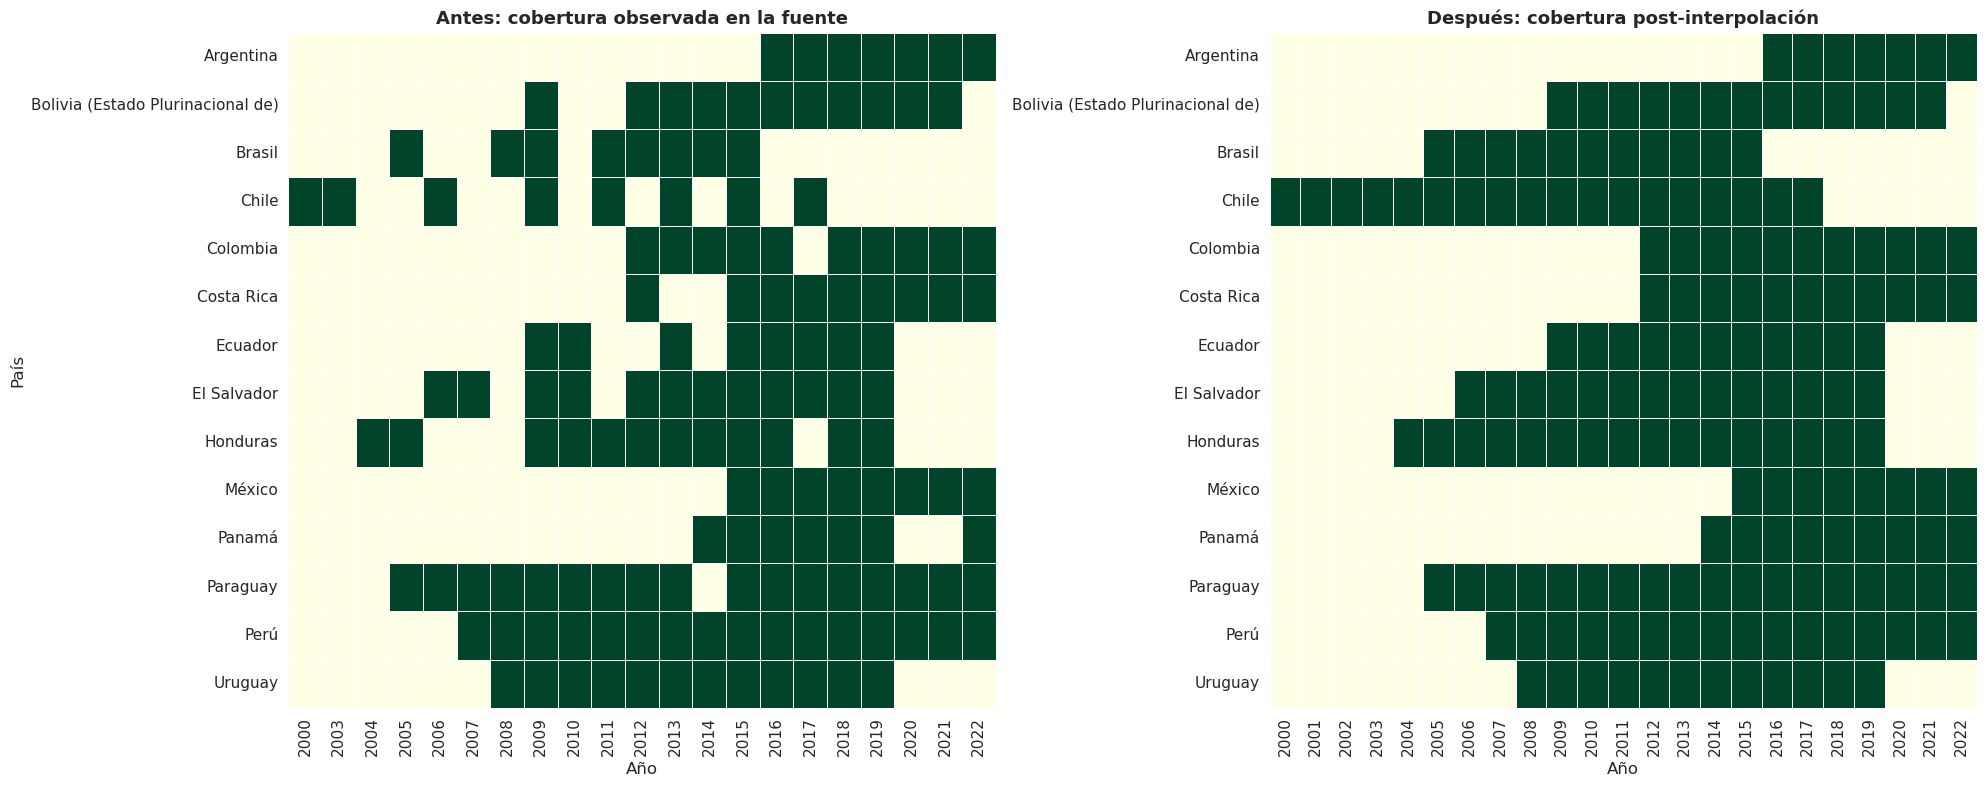

NAN RESIDUALES POR INDICADOR
pct_uso_<=17      0
pct_uso_18_25     0
pct_uso_26_50     0
pct_uso_51_65     0
pct_uso_66_mas    0
pct_uso_total     0

No hay NaN residuales en el dataset.


In [97]:
# Reconstruir la versión interpolada del grid (sin descartar filas todo-NaN)
# para visualizar la cobertura post-interpolación. Se usa transform — mismo
# patrón que en la celda anterior — para preservar la columna `pais`.
df_grid_interpolated = df_grid.sort_values(['pais', 'año']).copy()
df_grid_interpolated[INDICADORES] = (
    df_grid_interpolated.groupby('pais')[INDICADORES]
                        .transform(lambda s: s.interpolate(method='linear', limit_area='inside'))
)

presencia_post = (df_grid_interpolated
                  .assign(presente=df_grid_interpolated[INDICADORES].notna().any(axis=1).astype(int))
                  .pivot_table(index='pais', columns='año', values='presente', aggfunc='first')
                  .reindex(index=paises, columns=años)
                  .fillna(0)
                  .astype(int))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(presencia, cmap='YlGn', cbar=False, linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title('Antes: cobertura observada en la fuente', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('País')

sns.heatmap(presencia_post, cmap='YlGn', cbar=False, linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Después: cobertura post-interpolación', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

nan_residuales = df_interp[INDICADORES].isna().sum()
print('=' * 70)
print('NAN RESIDUALES POR INDICADOR')
print('=' * 70)
print(nan_residuales.to_string())

if nan_residuales.sum() > 0:
    print(f'\nDetalle: pares (país, indicador) con NaN residual (no imputables porque el país')
    print(f'no tiene NINGÚN valor observado para ese indicador):')
    print('─' * 50)
    for ind in INDICADORES:
        paises_nan = df_interp.loc[df_interp[ind].isna(), 'pais'].unique()
        if len(paises_nan) > 0:
            print(f'  {ind:18s}  →  {sorted(paises_nan)}')
else:
    print(f'\nNo hay NaN residuales en el dataset.')


---
### 5. Validación Intermedia del Dataset Imputado

**Forma, tipos y conteo de nulos finales**

In [98]:
print('=' * 70)
print('DATASET TRANSFORMADO - INFORMACIÓN FINAL')
print('=' * 70)
print(f'\nForma: {df_interp.shape}')
print(f'\nTipos de datos:')
print('─' * 50)
print(df_interp.dtypes.to_string())
print(f'\nValores nulos por columna:')
print('─' * 50)
print(df_interp.isna().sum().to_string())
print(f'\nMuestra:')
display(df_interp.head(10))

DATASET TRANSFORMADO - INFORMACIÓN FINAL

Forma: (175, 8)

Tipos de datos:
──────────────────────────────────────────────────
pais                  str
año                 int64
pct_uso_<=17      float64
pct_uso_18_25     float64
pct_uso_26_50     float64
pct_uso_51_65     float64
pct_uso_66_mas    float64
pct_uso_total     float64

Valores nulos por columna:
──────────────────────────────────────────────────
pais              0
año               0
pct_uso_<=17      0
pct_uso_18_25     0
pct_uso_26_50     0
pct_uso_51_65     0
pct_uso_66_mas    0
pct_uso_total     0

Muestra:


,pais,año,pct_uso_<=17,pct_uso_18_25,pct_uso_26_50,pct_uso_51_65,pct_uso_66_mas,pct_uso_total
0,Argentina,2016,75.900000,86.4,82.0,60.900000,28.6,71.1
1,Argentina,2017,75.900000,89.7,85.6,67.600000,34.0,74.4
2,Argentina,2018,78.500000,90.2,88.1,73.800000,39.7,77.7
3,Argentina,2019,78.900000,92.0,89.6,77.300000,46.1,80.0
4,Argentina,2020,87.500000,95.0,91.9,80.600000,54.5,85.6
5,Argentina,2021,86.900000,94.9,94.2,86.900000,57.4,87.2
6,Argentina,2022,86.500000,96.8,95.2,88.400000,62.7,88.5
7,Bolivia (Estado Plurinacional de),2009,30.200000,56.1,26.8,11.100000,2.5,29.5
8,Bolivia (Estado Plurinacional de),2010,33.166667,58.2,28.9,12.333333,2.9,31.5
9,Bolivia (Estado Plurinacional de),2011,36.133333,60.3,31.0,13.566667,3.3,33.5


**Estadísticas descriptivas de los seis indicadores**

In [99]:
desc = df_interp[INDICADORES].describe().T.round(2)
desc['fuera_rango'] = (
    ((df_interp[INDICADORES] < 0) | (df_interp[INDICADORES] > 100)).sum().values
)
display(desc)

valores = df_interp[INDICADORES].dropna()
fuera_rango_total = int(((valores < 0) | (valores > 100)).sum().sum())
assert fuera_rango_total == 0, f'Se encontraron {fuera_rango_total} valores fuera del rango [0, 100]'
print('\nValidación: todos los valores no nulos están en el rango [0, 100]. [OK]')

,count,mean,std,min,25%,50%,75%,max,fuera_rango
pct_uso_<=17,175.0,53.31,22.99,4.4,36.92,55.7,71.40,90.9,0
pct_uso_18_25,175.0,65.04,23.25,8.6,54.07,70.1,83.25,96.8,0
pct_uso_26_50,175.0,49.69,25.72,4.4,28.58,50.1,72.35,95.2,0
pct_uso_51_65,175.0,30.91,22.52,2.1,12.60,24.2,47.45,88.4,0
pct_uso_66_mas,175.0,13.17,14.40,0.2,3.10,7.2,17.90,62.7,0
pct_uso_total,175.0,46.59,21.39,5.0,30.65,47.5,63.95,88.5,0



Validación: todos los valores no nulos están en el rango [0, 100]. [OK]


**Sanity check visual: serie de un país antes y después de la interpolación**

País graficado:                       Chile
  Años observados en la fuente:       8
  Años en la serie interpolada:       18
  Años imputados (nuevos):            [2001, 2002, 2004, 2005, 2007, 2008, 2010, 2012, 2014, 2016]
  NaN residuales en pct_uso_total:      0


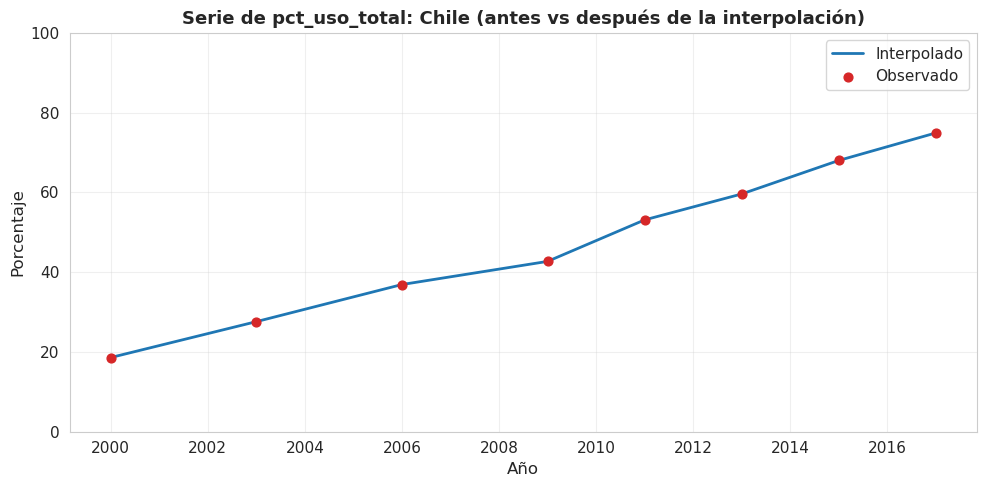

In [100]:
# Sanity check visual: serie de un país antes y después de la interpolación.
# Compara los puntos observados (df_wide) contra la trayectoria continua (df_interp)
# para verificar que la interpolación respeta las observaciones originales y
# produce una trayectoria localmente lineal entre ellas.

PAIS_PREFERIDO = 'Chile'
INDICADOR      = 'pct_uso_total'

# Selección defensiva del país: usar el preferido si está disponible en ambos
# DataFrames; caer al primer país en común en caso contrario.
paises_comunes = sorted(set(df_wide['pais']) & set(df_interp['pais']))
assert paises_comunes, 'No hay países en común entre df_wide y df_interp.'
pais_check = PAIS_PREFERIDO if PAIS_PREFERIDO in paises_comunes else paises_comunes[0]

obs    = df_wide  [df_wide  ['pais'] == pais_check].sort_values('año')
interp = df_interp[df_interp['pais'] == pais_check].sort_values('año')

años_obs    = set(obs   ['año'].astype(int))
años_interp = set(interp['año'].astype(int))

print(f'País graficado:                       {pais_check}')
print(f'  Años observados en la fuente:       {len(años_obs)}')
print(f'  Años en la serie interpolada:       {len(años_interp)}')
print(f'  Años imputados (nuevos):            {sorted(años_interp - años_obs)}')
print(f'  NaN residuales en {INDICADOR}:      {interp[INDICADOR].isna().sum()}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(   interp['año'], interp[INDICADOR], color='#1f77b4', linewidth=2,            label='Interpolado')
ax.scatter(obs   ['año'], obs   [INDICADOR], color='#d62728', s=40,        zorder=3,  label='Observado')
ax.set_title(f'Serie de {INDICADOR}: {pais_check} (antes vs después de la interpolación)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje')
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación de la validación intermedia**

- El dataset imputado tiene la forma esperada y todos los valores numéricos están en el rango físicamente válido `[0, 100]`.
- La interpolación es **respetuosa de los valores observados** (los puntos rojos coinciden con la línea azul) y produce una trayectoria localmente lineal entre ellos.
- Los NaN residuales documentados corresponden exclusivamente a indicadores que el país nunca reportó (no se imputan a la fuerza).

A partir de aquí se establece la **identidad única de `df_final`** que se mutará incrementalmente en las secciones 6-12 con outliers, ingeniería de variables, discretización, codificación y estandarización.

In [101]:
# Establecer la identidad única de df_final que se mutará incrementalmente
# en las secciones 6-12 antes de la exportación en la Sección 13.
df_final = df_interp.sort_values(['pais', 'año']).reset_index(drop=True)

# Aserciones de invariantes iniciales: protegen las mutaciones de las secciones
# posteriores (outliers, ingeniería de variables, discretización, codificación,
# estandarización) de partir de un estado inconsistente.
assert {'pais', 'año'}.issubset(df_final.columns),         'df_final debe contener las columnas pais y año.'
assert set(INDICADORES).issubset(df_final.columns),        'df_final debe contener los 6 indicadores.'
assert df_final.duplicated(['pais', 'año']).sum() == 0,    'No deben existir pares (pais, año) duplicados.'

print(f'df_final establecido: {df_final.shape[0]} filas × {df_final.shape[1]} columnas')
print(f'  Países únicos:    {df_final["pais"].nunique()}')
print(f'  Rango temporal:   {int(df_final["año"].min())}–{int(df_final["año"].max())}')
print(f'\nColumnas iniciales: {list(df_final.columns)}')


df_final establecido: 175 filas × 8 columnas
  Países únicos:    14
  Rango temporal:   2000–2022

Columnas iniciales: ['pais', 'año', 'pct_uso_<=17', 'pct_uso_18_25', 'pct_uso_26_50', 'pct_uso_51_65', 'pct_uso_66_mas', 'pct_uso_total']


---
### 6. Detección y Tratamiento de Outliers

Aunque el indicador es un porcentaje **acotado matemáticamente al rango `[0, 100]`** por construcción, es necesario realizar una de detección de outliers como parte de la limpieza de datos. Esta sección realiza un diagnóstico **doble (IQR + Z-score)** para documentar formalmente la decisión de tratamiento.

**Análisis IQR (Tukey) por indicador**

,Q1,Q3,IQR,lim_inf_tukey,lim_sup_tukey,n_outliers_iqr,pct_outliers
indicador,,,,,,,
pct_uso_<=17,36.92,71.40,34.48,-14.81,123.13,0,0.00
pct_uso_18_25,54.07,83.25,29.18,10.29,127.02,1,0.57
pct_uso_26_50,28.58,72.35,43.77,-37.07,138.00,0,0.00
pct_uso_51_65,12.60,47.45,34.85,-39.68,99.72,0,0.00
pct_uso_66_mas,3.10,17.90,14.80,-19.10,40.10,13,7.43
pct_uso_total,30.65,63.95,33.30,-19.30,113.90,0,0.00


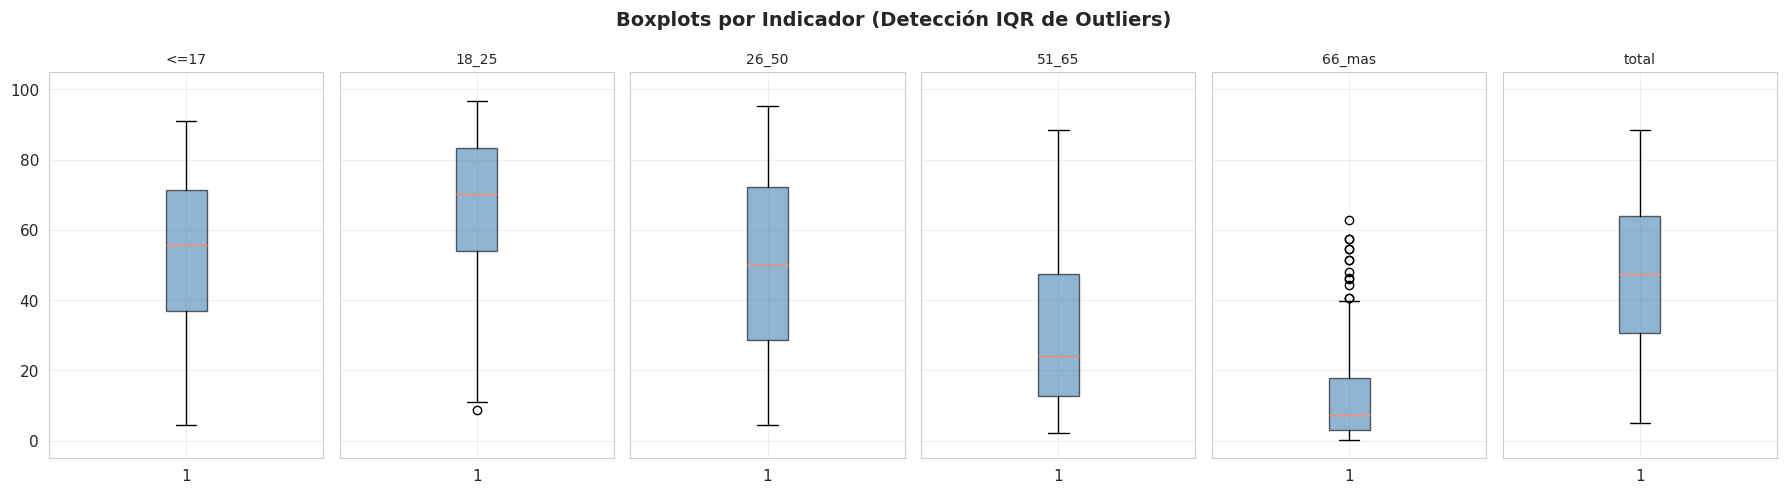

In [102]:
# Análisis IQR clásico de Tukey por cada indicador
iqr_resultados = []
for col in INDICADORES:
    serie = df_final[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    iqr_resultados.append({
        'indicador': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'lim_inf_tukey': round(lim_inf, 2),
        'lim_sup_tukey': round(lim_sup, 2),
        'n_outliers_iqr': int(n_outliers),
        'pct_outliers': round(n_outliers / len(serie) * 100, 2)
    })

df_outliers_iqr = pd.DataFrame(iqr_resultados).set_index('indicador')
display(df_outliers_iqr)

# Boxplot visual de los 6 indicadores
fig, axes = plt.subplots(1, 6, figsize=(18, 5), sharey=True)
for ax, col in zip(axes, INDICADORES):
    ax.boxplot(df_final[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col.replace('pct_uso_', ''), fontsize=10)
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)
fig.suptitle('Boxplots por Indicador (Detección IQR de Outliers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis Z-score por indicador (|z| > 3)**

In [103]:
# Análisis Z-score: contar valores extremos por desviación estándar
z_resultados = []
for col in INDICADORES:
    serie = df_final[col].dropna()
    z = sp_stats.zscore(serie)
    n_extremos = (np.abs(z) > 3).sum()
    z_resultados.append({
        'indicador': col,
        'media': round(serie.mean(), 2),
        'std': round(serie.std(), 2),
        'z_min': round(z.min(), 2),
        'z_max': round(z.max(), 2),
        'n_extremos_abs_z_gt3': int(n_extremos),
        'pct_extremos': round(n_extremos / len(serie) * 100, 2)
    })

df_outliers_z = pd.DataFrame(z_resultados).set_index('indicador')
display(df_outliers_z)

,media,std,z_min,z_max,n_extremos_abs_z_gt3,pct_extremos
indicador,,,,,,
pct_uso_<=17,53.31,22.99,-2.13,1.64,0,0.00
pct_uso_18_25,65.04,23.25,-2.43,1.37,0,0.00
pct_uso_26_50,49.69,25.72,-1.77,1.77,0,0.00
pct_uso_51_65,30.91,22.52,-1.28,2.56,0,0.00
pct_uso_66_mas,13.17,14.40,-0.90,3.45,3,1.71
pct_uso_total,46.59,21.39,-1.95,1.97,0,0.00


**Decisión documentada: NO se aplican correcciones**

El diagnóstico revela algunos puntos en los extremos según ambos criterios. Sin embargo, **no se aplican correcciones** por las siguientes razones:

1. **Acotación física:** los valores son porcentajes en `[0, 100]` por construcción del indicador. No existen valores físicamente imposibles.
2. **Los "outliers" son señal, no ruido:** los valores extremos altos corresponden a países líderes en adopción digital (Argentina, Chile, Costa Rica) y los extremos bajos a países rezagados (Honduras, El Salvador). Eliminarlos sesgaría hacia la mediana regional, perdiendo el patrón de heterogeneidad inter-país que el modelo debe aprender.
3. **Tamaño muestral:** con sólo 175 observaciones, descartar puntos legítimos comprometería la robustez estadística.
4. **Modelos robustos:** los algoritmos previstos para la Semana 3 (árboles, regresión regularizada, KNN) son razonablemente robustos ante valores extremos no patológicos.

**Conclusión:** se conservan todos los valores. La sección queda solo documentada como diagnóstico-confirmatorio de la calidad del dataset.

---
### 7. Ingeniería de Variables

Esta sección genera **17 nuevas features** a partir del conocimiento del dominio y de la estructura de panel del dataset, organizadas en cuatro familias:

| Familia | Nº features | Propósito |
|---|---|---|
| Brechas intergeneracionales | 3 | Capturar el insight central de la Semana 1: la diferencia entre grupos etarios. |
| Lags temporales (1 año) | 6 | Modelar dependencia AR(1) intra-país, estándar en panel data. |
| Deltas anuales | 6 | Variación absoluta año-a-año (tasa de adopción). |
| Variables temporales | 2 | Tendencia macro común y madurez de la serie nacional. |
| **Total** | **17** | |

> **Nota sobre NaN inducidos:** las features de tipo lag y delta introducen 14 NaN cada una (uno por país en su primer año observado). Estos NaN **se mantienen documentados, sin imputar**, porque el primer año de cada país es genuinamente no-derivable. La Fase de Modelado decidirá cómo tratarlos según el algoritmo.

#### 7.1 Brechas Intergeneracionales

**Cálculo de las 3 brechas: joven-mayor, total-mayor, joven-total**

In [104]:
# Brecha intergeneracional: insight central identificado en la Semana 1
df_final['brecha_joven_mayor'] = df_final['pct_uso_18_25'] - df_final['pct_uso_66_mas']
df_final['brecha_total_mayor'] = df_final['pct_uso_total'] - df_final['pct_uso_66_mas']
df_final['brecha_joven_total'] = df_final['pct_uso_18_25'] - df_final['pct_uso_total']

BRECHAS = ['brecha_joven_mayor', 'brecha_total_mayor', 'brecha_joven_total']

print('Estadísticas descriptivas de las 3 brechas:')
display(df_final[BRECHAS].describe().round(2))

print(f'\nMuestra (primeras 8 filas):')
display(df_final[['pais', 'año'] + BRECHAS].head(8))

Estadísticas descriptivas de las 3 brechas:


,brecha_joven_mayor,brecha_total_mayor,brecha_joven_total
count,175.00,175.00,175.00
mean,51.87,33.42,18.45
std,17.58,12.43,7.19
min,7.90,4.30,3.60
25%,39.05,25.35,12.80
50%,57.00,35.50,19.50
75%,65.30,43.47,23.85
max,77.40,55.20,33.30



Muestra (primeras 8 filas):


,pais,año,brecha_joven_mayor,brecha_total_mayor,brecha_joven_total
0,Argentina,2016,57.8,42.5,15.3
1,Argentina,2017,55.7,40.4,15.3
2,Argentina,2018,50.5,38.0,12.5
3,Argentina,2019,45.9,33.9,12.0
4,Argentina,2020,40.5,31.1,9.4
5,Argentina,2021,37.5,29.8,7.7
6,Argentina,2022,34.1,25.8,8.3
7,Bolivia (Estado Plurinacional de),2009,53.6,27.0,26.6


#### 7.2 Lags Temporales (1 año)

**Generación de 6 lags por país, ordenados por año**

In [105]:
# Lags temporales: shift(1) por país tras ordenar por año
df_final = df_final.sort_values(['pais', 'año']).reset_index(drop=True)

LAGS = [f'{c}_lag1' for c in INDICADORES]
df_final[LAGS] = df_final.groupby('pais')[INDICADORES].shift(1)

print(f'Lags generados: {len(LAGS)} columnas')
print(f'\nNaN por columna lag (esperado: 14, uno por país en su primer año):')
print(df_final[LAGS].isna().sum().to_string())

print(f'\nMuestra (Argentina, primeros 5 años — observe el primer NaN en lag):')
display(df_final[df_final['pais'] == 'Argentina'][['pais', 'año', 'pct_uso_total', 'pct_uso_total_lag1']].head())

Lags generados: 6 columnas

NaN por columna lag (esperado: 14, uno por país en su primer año):
pct_uso_<=17_lag1      14
pct_uso_18_25_lag1     14
pct_uso_26_50_lag1     14
pct_uso_51_65_lag1     14
pct_uso_66_mas_lag1    14
pct_uso_total_lag1     14

Muestra (Argentina, primeros 5 años — observe el primer NaN en lag):


,pais,año,pct_uso_total,pct_uso_total_lag1
0,Argentina,2016,71.1,NaN
1,Argentina,2017,74.4,71.1
2,Argentina,2018,77.7,74.4
3,Argentina,2019,80.0,77.7
4,Argentina,2020,85.6,80.0


#### 7.3 Deltas Anuales

**Generación de 6 deltas: variación año-a-año por indicador**

In [106]:
# Deltas anuales: diferencia respecto al año anterior por país
DELTAS = [f'delta_{c}' for c in INDICADORES]
df_final[DELTAS] = df_final[INDICADORES].values - df_final[LAGS].values

print(f'Deltas generados: {len(DELTAS)} columnas')
print(f'\nEstadísticas descriptivas de los deltas:')
display(df_final[DELTAS].describe().round(2))

Deltas generados: 6 columnas

Estadísticas descriptivas de los deltas:


,delta_pct_uso_<=17,delta_pct_uso_18_25,delta_pct_uso_26_50,delta_pct_uso_51_65,delta_pct_uso_66_mas,delta_pct_uso_total
count,161.00,161.00,161.00,161.00,161.00,161.00
mean,2.76,3.44,4.03,3.49,2.10,3.28
std,4.24,2.72,2.66,2.80,2.28,2.22
min,-10.90,-6.50,-3.10,-5.00,-1.90,-3.30
25%,0.60,1.90,2.20,1.30,0.50,2.00
50%,2.50,3.20,3.73,3.00,1.30,3.10
75%,4.70,4.80,5.80,5.50,3.20,4.40
max,22.30,12.20,12.50,12.10,10.00,12.40


Observación: la mayoría de deltas son positivos, confirmando la tendencia creciente de adopción digital identificada en el EDA de la Semana 1.

#### 7.4 Variables Temporales

**Generación de 2 variables temporales: tendencia macro y madurez nacional**

In [107]:
# Variables temporales: tendencia macro común y madurez de la serie nacional
df_final['años_desde_2000'] = df_final['año'] - 2000

primer_año_pais = df_final.groupby('pais')['año'].transform('min')
df_final['años_desde_primer_registro_pais'] = df_final['año'] - primer_año_pais

TEMPORALES = ['años_desde_2000', 'años_desde_primer_registro_pais']

# Validar no-negatividad de la segunda variable
assert (df_final['años_desde_primer_registro_pais'] >= 0).all(), 'Hay valores negativos inesperados'

print('Variables temporales generadas:')
display(df_final[['pais', 'año'] + TEMPORALES].head(10))

print(f'\nRangos:')
print(f'  años_desde_2000:                   [{df_final["años_desde_2000"].min()}, {df_final["años_desde_2000"].max()}]')
print(f'  años_desde_primer_registro_pais:   [{df_final["años_desde_primer_registro_pais"].min()}, {df_final["años_desde_primer_registro_pais"].max()}]')

Variables temporales generadas:


,pais,año,años_desde_2000,años_desde_primer_registro_pais
0,Argentina,2016,16,0
1,Argentina,2017,17,1
2,Argentina,2018,18,2
3,Argentina,2019,19,3
4,Argentina,2020,20,4
5,Argentina,2021,21,5
6,Argentina,2022,22,6
7,Bolivia (Estado Plurinacional de),2009,9,0
8,Bolivia (Estado Plurinacional de),2010,10,1
9,Bolivia (Estado Plurinacional de),2011,11,2



Rangos:
  años_desde_2000:                   [0, 22]
  años_desde_primer_registro_pais:   [0, 17]


**Resumen de features ingeniadas**

In [108]:
# Resumen del estado de df_final tras ingeniería de variables
print('=' * 70)
print('RESUMEN DE FEATURE ENGINEERING')
print('=' * 70)

resumen_fe = pd.DataFrame({
    'Familia': ['Brechas', 'Lags temporales', 'Deltas anuales', 'Variables temporales', 'TOTAL'],
    'Nº features': [len(BRECHAS), len(LAGS), len(DELTAS), len(TEMPORALES),
                    len(BRECHAS) + len(LAGS) + len(DELTAS) + len(TEMPORALES)]
})
display(resumen_fe.set_index('Familia'))

print(f'\nForma actual de df_final: {df_final.shape}')

RESUMEN DE FEATURE ENGINEERING


,Nº features
Familia,
Brechas,3
Lags temporales,6
Deltas anuales,6
Variables temporales,2
TOTAL,17



Forma actual de df_final: (175, 25)


---
### 8. Discretización

Se discretiza `pct_uso_total` en una variable categórica ordinal `categoria_adopcion` con cuatro niveles, basados en umbrales que aproximan los cuartiles del dataset:

| Categoría | Rango | Interpretación |
|---|---|---|
| `Inicial` | < 25% | Adopción muy temprana, mayoría sin acceso. |
| `Emergente` | [25%, 50%) | Adopción creciente pero minoritaria. |
| `Avanzada` | [50%, 75%) | Mayoría conectada, transición digital activa. |
| `Madura` | ≥ 75% | Adopción consolidada, convergencia digital. |

Esta variable categórica habilita modelos de **clasificación** en la Semana 3 (árboles, naive Bayes, regresión logística multinomial), complementando el target continuo `pct_uso_total` para regresión.

**Aplicación de pd.cut con bins fijos sobre pct_uso_total**

In [109]:
# Discretización con pd.cut usando umbrales fijos
BINS_ADOPCION = [-0.001, 25, 50, 75, 100.001]
ETIQUETAS_ADOPCION = ['Inicial', 'Emergente', 'Avanzada', 'Madura']

df_final['categoria_adopcion'] = pd.cut(
    df_final['pct_uso_total'],
    bins=BINS_ADOPCION,
    labels=ETIQUETAS_ADOPCION,
    include_lowest=True
)

# Validar: ningún NaN en la columna nueva
assert df_final['categoria_adopcion'].notna().all(), 'NaN inesperado en categoria_adopcion'

print('Distribución de la variable categoria_adopcion:')
print('─' * 50)
print(df_final['categoria_adopcion'].value_counts().reindex(ETIQUETAS_ADOPCION).to_string())

print(f'\nProporciones (%):')
print((df_final['categoria_adopcion'].value_counts(normalize=True).reindex(ETIQUETAS_ADOPCION) * 100).round(1).to_string())

Distribución de la variable categoria_adopcion:
──────────────────────────────────────────────────
categoria_adopcion
Inicial      32
Emergente    63
Avanzada     63
Madura       17

Proporciones (%):
categoria_adopcion
Inicial      18.3
Emergente    36.0
Avanzada     36.0
Madura        9.7


**Crosstab y visualización: distribución de categorías por país**

categoria_adopcion,Inicial,Emergente,Avanzada,Madura,Total
pais,,,,,
Argentina,0,0,2,5,7
Bolivia (Estado Plurinacional de),0,11,2,0,13
Brasil,1,8,2,0,11
Chile,3,8,7,0,18
Colombia,0,1,10,0,11
Costa Rica,0,1,6,4,11
Ecuador,1,5,5,0,11
El Salvador,9,4,1,0,14
Honduras,11,5,0,0,16


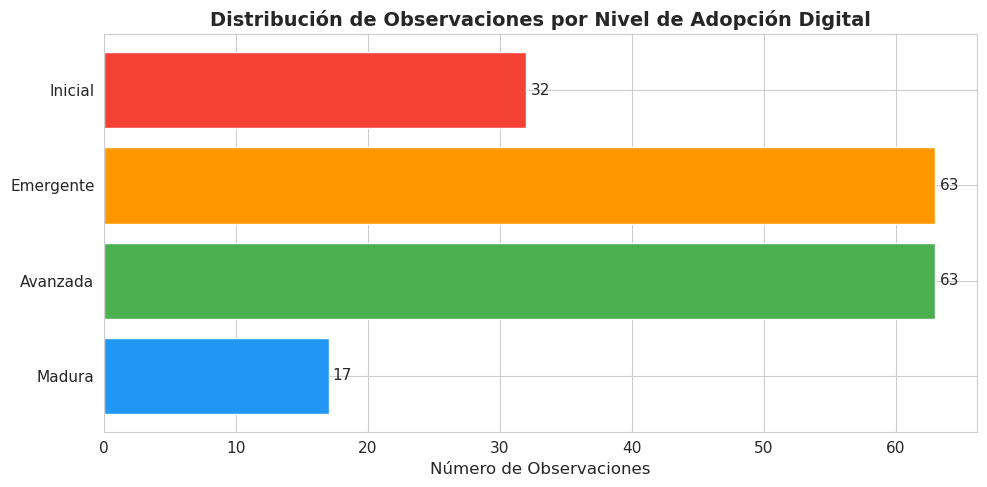

In [110]:
# Crosstab para entender qué países aportan a cada categoría
crosstab = pd.crosstab(df_final['pais'], df_final['categoria_adopcion'],
                       margins=True, margins_name='Total')
display(crosstab)

# Visualización: barplot de conteos por categoría
fig, ax = plt.subplots(figsize=(10, 5))
conteos = df_final['categoria_adopcion'].value_counts().reindex(ETIQUETAS_ADOPCION)
colores_cat = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
bars = ax.barh(conteos.index, conteos.values, color=colores_cat, edgecolor='white')
ax.set_xlabel('Número de Observaciones')
ax.set_title('Distribución de Observaciones por Nivel de Adopción Digital',
             fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
### 9. Codificación de Variables Categóricas

La única variable categórica nominal del dataset es `pais` (14 categorías). Se aplica **one-hot encoding** con `drop_first=True` para evitar la multicolinealidad perfecta (trampa de la variable dummy) que afectaría a modelos lineales.

| Estrategia | Decisión | Razón |
|---|---|---|
| One-hot (`drop_first=True`) | **Adoptada** | Estándar para nominales sin orden; compatible con modelos lineales y de árbol. |
| Target encoding | Descartada | Riesgo de leakage al usar el target en la codificación. |
| Ordinal/Label | Descartada | Los países no tienen un orden natural; introduciría una jerarquía artificial. |

La variable `categoria_adopcion` (ordinal, creada en la Sección 8) **no se codifica aquí**: la Fase de Modelado decidirá entre tratarla como ordinal numérica o como dummy según el algoritmo y el rol que tome (target vs feature).

**One-hot encoding de pais con drop_first=True**

In [111]:
# One-hot encoding de pais. Los dummies se almacenan separados; se concatenarán
# a df_final en la Sección 13 para construir el CSV final.
dummies_pais = pd.get_dummies(df_final['pais'], prefix='pais', drop_first=True, dtype=int)

pais_referencia = sorted(df_final['pais'].unique())[0]
print(f'Dummies generados: {dummies_pais.shape[1]} columnas (14 países − 1 referencia)')
print(f'País de referencia (excluido del one-hot): {pais_referencia}')
print(f'\nColumnas dummy:')
for c in dummies_pais.columns:
    print(f'  - {c}')

print(f'\nMuestra:')
display(dummies_pais.head())

Dummies generados: 13 columnas (14 países − 1 referencia)
País de referencia (excluido del one-hot): Argentina

Columnas dummy:
  - pais_Bolivia (Estado Plurinacional de)
  - pais_Brasil
  - pais_Chile
  - pais_Colombia
  - pais_Costa Rica
  - pais_Ecuador
  - pais_El Salvador
  - pais_Honduras
  - pais_México
  - pais_Panamá
  - pais_Paraguay
  - pais_Perú
  - pais_Uruguay

Muestra:


,pais_Bolivia (Estado Plurinacional de),pais_Brasil,pais_Chile,pais_Colombia,pais_Costa Rica,pais_Ecuador,pais_El Salvador,pais_Honduras,pais_México,pais_Panamá,pais_Paraguay,pais_Perú,pais_Uruguay
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0


---
### 10. Normalización / Estandarización

Se aplica **StandardScaler** (centrado en media 0, escalado a desviación estándar 1) sobre 21 features numéricas. Esta transformación es necesaria para algoritmos sensibles a la escala:

- **Modelos basados en distancia:** KNN, k-means, SVM (kernel RBF).
- **Redes neuronales:** convergencia más rápida y estable.
- **Modelos lineales con regularización:** Ridge, Lasso, ElasticNet (la regularización se vuelve sesgada si las escalas difieren).

**Decisión: StandardScaler en lugar de MinMaxScaler** porque (a) las distribuciones de los indicadores son aproximadamente normales según el EDA, (b) preserva la información de extremos sin aplastarlos al rango fijo `[0, 1]`, y (c) los modelos lineales regularizados se comportan mejor sobre features centradas en cero.

**Conjunto a escalar (21 features):** 6 indicadores raw + 3 brechas + 6 lags + 6 deltas. Las 2 variables temporales **NO se escalan** porque su semántica como enteros (años transcurridos) es más interpretable que sus valores estandarizados.

**Definición del conjunto de columnas a estandarizar**

In [112]:
COLUMNAS_A_ESCALAR = INDICADORES + BRECHAS + LAGS + DELTAS

print(f'Conjunto a escalar: {len(COLUMNAS_A_ESCALAR)} columnas')
for c in COLUMNAS_A_ESCALAR:
    print(f'  - {c}')

print(f'\nEstadísticas pre-escalado (para comparar con post-escalado):')
display(df_final[COLUMNAS_A_ESCALAR].describe().T[['mean', 'std', 'min', 'max']].round(2))

Conjunto a escalar: 21 columnas
  - pct_uso_<=17
  - pct_uso_18_25
  - pct_uso_26_50
  - pct_uso_51_65
  - pct_uso_66_mas
  - pct_uso_total
  - brecha_joven_mayor
  - brecha_total_mayor
  - brecha_joven_total
  - pct_uso_<=17_lag1
  - pct_uso_18_25_lag1
  - pct_uso_26_50_lag1
  - pct_uso_51_65_lag1
  - pct_uso_66_mas_lag1
  - pct_uso_total_lag1
  - delta_pct_uso_<=17
  - delta_pct_uso_18_25
  - delta_pct_uso_26_50
  - delta_pct_uso_51_65
  - delta_pct_uso_66_mas
  - delta_pct_uso_total

Estadísticas pre-escalado (para comparar con post-escalado):


,mean,std,min,max
pct_uso_<=17,53.31,22.99,4.4,90.9
pct_uso_18_25,65.04,23.25,8.6,96.8
pct_uso_26_50,49.69,25.72,4.4,95.2
pct_uso_51_65,30.91,22.52,2.1,88.4
pct_uso_66_mas,13.17,14.40,0.2,62.7
pct_uso_total,46.59,21.39,5.0,88.5
brecha_joven_mayor,51.87,17.58,7.9,77.4
brecha_total_mayor,33.42,12.43,4.3,55.2
brecha_joven_total,18.45,7.19,3.6,33.3
pct_uso_<=17_lag1,51.81,22.90,4.4,90.4


**Aplicación de StandardScaler preservando NaN columna a columna**

In [113]:
# StandardScaler no maneja NaN nativamente. Estrategia: aplicar columna a columna,
# escalando solo los valores no nulos y conservando los NaN en su posición original.
# Esto preserva más información que filtrar filas completas con NaN.

cols_z = [f'{c}_z' for c in COLUMNAS_A_ESCALAR]

for col, col_z in zip(COLUMNAS_A_ESCALAR, cols_z):
    valores = df_final[col].values.astype(float)
    mascara = ~np.isnan(valores)
    df_final[col_z] = np.nan
    if mascara.sum() > 0:
        scaler = StandardScaler()
        df_final.loc[mascara, col_z] = scaler.fit_transform(
            valores[mascara].reshape(-1, 1)
        ).flatten()

print(f'Columnas estandarizadas creadas: {len(cols_z)}')
print(f'Forma actual de df_final: {df_final.shape}')

Columnas estandarizadas creadas: 21
Forma actual de df_final: (175, 47)


**Validación: media ≈ 0, desviación estándar ≈ 1 en columnas _z**

In [114]:
# Validar que las columnas _z tienen las propiedades esperadas
desc_z = df_final[cols_z].describe().T[['mean', 'std', 'min', 'max']].round(4)
display(desc_z)

# Aserciones con tolerancia numérica
mean_max_abs = df_final[cols_z].mean().abs().max()
std_max_dev = (df_final[cols_z].std() - 1).abs().max()

assert mean_max_abs < 1e-9, f'Alguna columna _z tiene media != 0 (max abs = {mean_max_abs})'
print(f'Máxima media absoluta en columnas _z:        {mean_max_abs:.2e} (esperado: ~0)')
print(f'Máxima desviación de std=1 en columnas _z:   {std_max_dev:.4f}')
print(f'\nValidación OK: las 21 columnas estandarizadas tienen mean≈0 y std≈1.')

,mean,std,min,max
pct_uso_<=17_z,0.0,1.0029,-2.1335,1.6394
pct_uso_18_25_z,-0.0,1.0029,-2.4343,1.3699
pct_uso_26_50_z,0.0,1.0029,-1.7657,1.7746
pct_uso_51_65_z,0.0,1.0029,-1.2829,2.5606
pct_uso_66_mas_z,-0.0,1.0029,-0.9037,3.4501
pct_uso_total_z,0.0,1.0029,-1.9503,1.9653
brecha_joven_mayor_z,0.0,1.0029,-2.5078,1.4565
brecha_total_mayor_z,0.0,1.0029,-2.3489,1.7573
brecha_joven_total_z,0.0,1.0029,-2.0714,2.0717
pct_uso_<=17_lag1_z,-0.0,1.0031,-2.0764,1.6903


Máxima media absoluta en columnas _z:        3.86e-16 (esperado: ~0)
Máxima desviación de std=1 en columnas _z:   0.0031

Validación OK: las 21 columnas estandarizadas tienen mean≈0 y std≈1.


---
### 11. Reducción de Datos: Análisis de Redundancia

Se distinguen dos enfoques:

- **Reducción destructiva:** eliminar columnas altamente correlacionadas.
- **Reducción documentada:** identificar candidatos a eliminación pero conservarlos para que la fase de modelado decida.

**Decisión: reducción documentada (NO destructiva).** Razones:
1. Diferentes algoritmos toleran multicolinealidad de manera distinta: los **árboles** (Random Forest, XGBoost) son indiferentes a colinealidad; los **lineales sin regularización** son sensibles; la **regularización** (Ridge/Lasso) la maneja explícitamente.
2. Eliminar columnas aquí impondría una decisión que no es óptima para todos los algoritmos.
3. Documentar pares con `|r| > 0.95` informa al equipo de modelado sin restringirlo.

**Matriz de correlación entre features numéricas**

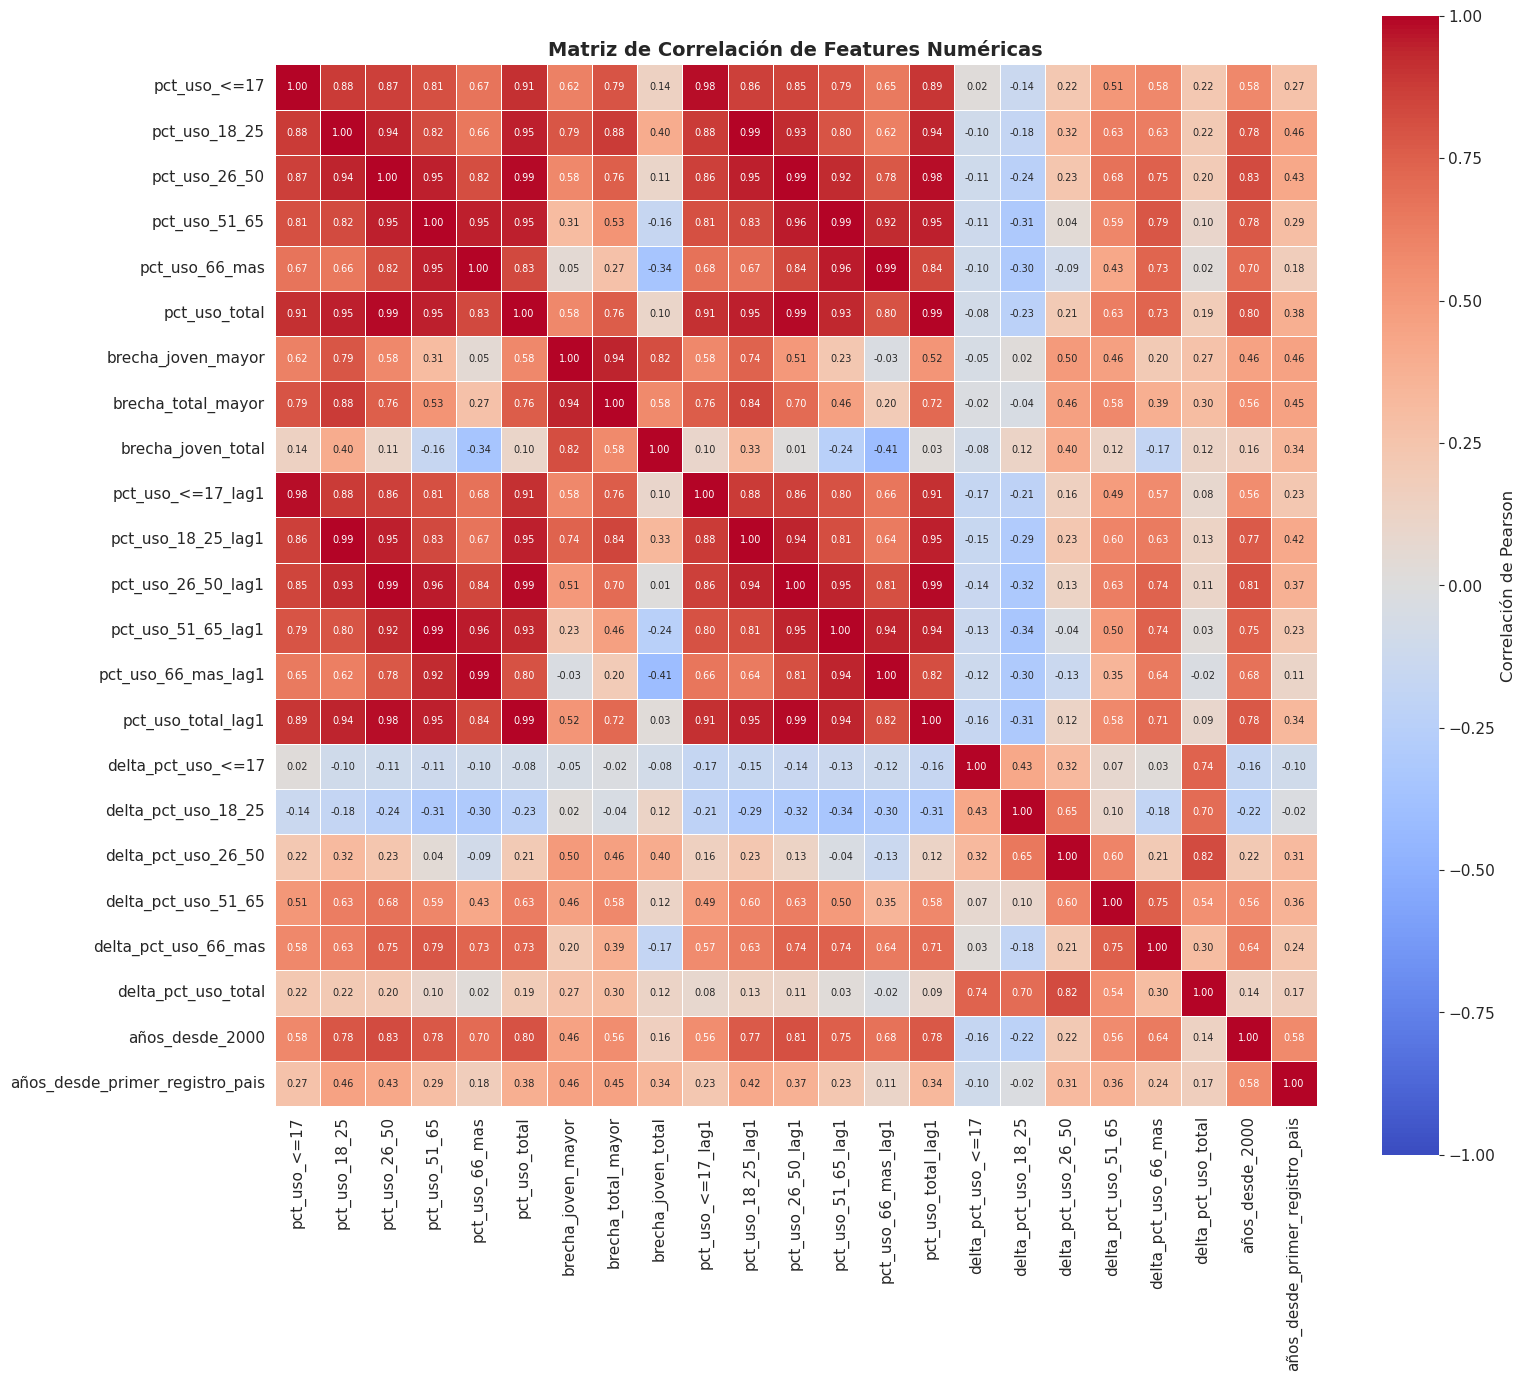

In [115]:
# Calcular matriz de correlación de las features numéricas
features_numericas = INDICADORES + BRECHAS + LAGS + DELTAS + TEMPORALES
corr = df_final[features_numericas].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize': 7}, ax=ax,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de Correlación de Features Numéricas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Identificación de pares con |r| > 0.95 (candidatos a redundancia)**

In [116]:
# Extraer pares del triángulo superior de la matriz con |r| > umbral
UMBRAL_REDUNDANCIA = 0.95

pares = []
for i in range(len(features_numericas)):
    for j in range(i + 1, len(features_numericas)):
        r = corr.iloc[i, j]
        if abs(r) > UMBRAL_REDUNDANCIA:
            pares.append({
                'feature_1': features_numericas[i],
                'feature_2': features_numericas[j],
                'r': round(r, 4)
            })

if pares:
    pares_redundantes = pd.DataFrame(pares).sort_values('r', key=abs, ascending=False).reset_index(drop=True)
else:
    pares_redundantes = pd.DataFrame(columns=['feature_1', 'feature_2', 'r'])

print(f'Pares con |r| > {UMBRAL_REDUNDANCIA} detectados: {len(pares_redundantes)}')
if len(pares_redundantes) > 0:
    display(pares_redundantes)
    print(f'\nDecisión: estos pares quedan documentados como candidatos a reducción.')
    print(f'La Fase de Modelado (Semana 3) decidirá según el algoritmo si eliminar alguna feature.')
else:
    print('\nNo hay redundancias críticas. Todas las features aportan información distintiva.')

Pares con |r| > 0.95 detectados: 16


,feature_1,feature_2,r
0,pct_uso_26_50,pct_uso_26_50_lag1,0.9946
1,pct_uso_total,pct_uso_total_lag1,0.9945
2,pct_uso_51_65,pct_uso_51_65_lag1,0.9942
3,pct_uso_18_25,pct_uso_18_25_lag1,0.9933
4,pct_uso_66_mas,pct_uso_66_mas_lag1,0.9929
5,pct_uso_26_50,pct_uso_total,0.9901
6,pct_uso_26_50_lag1,pct_uso_total_lag1,0.9899
7,pct_uso_total,pct_uso_26_50_lag1,0.9873
8,pct_uso_26_50,pct_uso_total_lag1,0.9834
9,pct_uso_<=17,pct_uso_<=17_lag1,0.9827



Decisión: estos pares quedan documentados como candidatos a reducción.
La Fase de Modelado (Semana 3) decidirá según el algoritmo si eliminar alguna feature.


---
### 12. Validación Final del Dataset Modelable

**Forma, dtypes y conteo de NaN finales**

In [117]:
print('=' * 70)
print('VALIDACIÓN FINAL DEL DATASET MODELABLE')
print('=' * 70)
print(f'\nForma de df_final: {df_final.shape}')

print(f'\nDistribución de tipos de datos:')
print(df_final.dtypes.value_counts().to_string())

# NaN por categoría de columnas
nan_por_col = df_final.isna().sum()
nan_relevantes = nan_por_col[nan_por_col > 0].sort_values(ascending=False)

if len(nan_relevantes) > 0:
    print(f'\nColumnas con NaN (todos esperados, atribuibles al primer año por país):')
    print('─' * 50)
    print(nan_relevantes.to_string())
    print(f'\nTotal de NaN: {int(nan_por_col.sum())}')
else:
    print(f'\nSin NaN en df_final.')

VALIDACIÓN FINAL DEL DATASET MODELABLE

Forma de df_final: (175, 47)

Distribución de tipos de datos:
float64     42
int64        3
str          1
category     1

Columnas con NaN (todos esperados, atribuibles al primer año por país):
──────────────────────────────────────────────────
pct_uso_<=17_lag1         14
pct_uso_18_25_lag1        14
pct_uso_26_50_lag1        14
pct_uso_51_65_lag1        14
pct_uso_66_mas_lag1       14
pct_uso_total_lag1        14
delta_pct_uso_<=17        14
delta_pct_uso_18_25       14
delta_pct_uso_26_50       14
delta_pct_uso_51_65       14
delta_pct_uso_66_mas      14
delta_pct_uso_total       14
pct_uso_<=17_lag1_z       14
pct_uso_18_25_lag1_z      14
pct_uso_26_50_lag1_z      14
pct_uso_51_65_lag1_z      14
pct_uso_66_mas_lag1_z     14
pct_uso_total_lag1_z      14
delta_pct_uso_<=17_z      14
delta_pct_uso_18_25_z     14
delta_pct_uso_26_50_z     14
delta_pct_uso_51_65_z     14
delta_pct_uso_66_mas_z    14
delta_pct_uso_total_z     14

Total de NaN: 336

**Sanity checks programáticos**

In [118]:
# Aserciones finales sobre la integridad del dataset
print('Ejecutando sanity checks programáticos...')
print('─' * 50)

# Check 1: número de filas
n_filas = len(df_final)
assert n_filas == 175, f'Esperado: 175 filas. Actual: {n_filas}'
print(f'  [OK] {n_filas} filas (sin cambio respecto a Sec 5).')

# Check 2: número de países únicos
n_paises = df_final['pais'].nunique()
assert n_paises == 14, f'Esperado: 14 países. Actual: {n_paises}'
print(f'  [OK] {n_paises} países únicos.')

# Check 3: categoria_adopcion sin NaN
assert df_final['categoria_adopcion'].notna().all(), 'NaN inesperado en categoria_adopcion'
print(f'  [OK] categoria_adopcion sin NaN.')

# Check 4: indicadores raw en [0, 100]
fuera_rango = ((df_final[INDICADORES] < 0) | (df_final[INDICADORES] > 100)).sum().sum()
assert fuera_rango == 0, f'Valores fuera de [0,100]: {fuera_rango}'
print(f'  [OK] Indicadores raw en rango [0, 100].')

# Check 5: columnas _z con mean ≈ 0
mean_max = df_final[cols_z].mean().abs().max()
assert mean_max < 1e-9, f'Columnas _z con media != 0 (max: {mean_max})'
print(f'  [OK] Columnas _z con media ≈ 0 (max abs = {mean_max:.2e}).')

# Check 6: dummies coherentes
assert dummies_pais.shape[0] == df_final.shape[0], 'Dummies y df_final con distintas filas'
assert dummies_pais.shape[1] == 13, f'Esperado: 13 dummies. Actual: {dummies_pais.shape[1]}'
print(f'  [OK] dummies_pais coherente: {dummies_pais.shape}.')

print(f'\nTodas las validaciones pasaron. El dataset está listo para exportación.')

Ejecutando sanity checks programáticos...
──────────────────────────────────────────────────
  [OK] 175 filas (sin cambio respecto a Sec 5).
  [OK] 14 países únicos.
  [OK] categoria_adopcion sin NaN.
  [OK] Indicadores raw en rango [0, 100].
  [OK] Columnas _z con media ≈ 0 (max abs = 3.86e-16).
  [OK] dummies_pais coherente: (175, 13).

Todas las validaciones pasaron. El dataset está listo para exportación.


---
### 13. Exportación del Conjunto de Datos Final

Se exporta un **único CSV comprehensivo** (`data_transformado.csv`) que combina todas las representaciones generadas en las secciones previas:

| Bloque de columnas | Cant. | Origen |
|---|---|---|
| Llaves | 2 | `pais`, `año` |
| Indicadores raw | 6 | Pivote (Sec 2-3) |
| Brechas intergeneracionales | 3 | Feature engineering (Sec 7.1) |
| Lags temporales | 6 | Feature engineering (Sec 7.2) |
| Deltas anuales | 6 | Feature engineering (Sec 7.3) |
| Variables temporales | 2 | Feature engineering (Sec 7.4) |
| Categoría discretizada | 1 | Discretización (Sec 8) |
| Dummies one-hot de país | 13 | Encoding (Sec 9) |
| Features estandarizadas | 21 | Normalización (Sec 10) |
| **Total** | **60** | |

La Fase de Modelado (Semana 3) seleccionará subconjuntos de columnas según cada algoritmo (e.g., features `_z` para KNN/SVM, raw para árboles, dummies para regresión lineal).

**Construcción del DataFrame comprehensivo y persistencia a CSV**

In [119]:
# Construir el DataFrame final concatenando df_final con dummies_pais
df_export = pd.concat([df_final.reset_index(drop=True),
                       dummies_pais.reset_index(drop=True)], axis=1)

# Ordenar columnas en bloques semánticos
LLAVES = ['pais', 'año']
CATEGORICA = ['categoria_adopcion']
DUMMIES_COLS = list(dummies_pais.columns)
COLUMNAS_FINALES = (LLAVES + INDICADORES + BRECHAS + LAGS + DELTAS +
                     TEMPORALES + CATEGORICA + DUMMIES_COLS + cols_z)
df_export = df_export[COLUMNAS_FINALES]

# Sort y guardar
RUTA_CSV = 'data_transformado.csv'
df_export = df_export.sort_values(['pais', 'año']).reset_index(drop=True)
df_export.to_csv(RUTA_CSV, index=False, encoding='utf-8')

tamano_bytes = os.path.getsize(RUTA_CSV)
print(f'Archivo CSV escrito exitosamente: {RUTA_CSV}')
print(f'  Tamaño en disco: {tamano_bytes:,} bytes ({tamano_bytes/1024:.1f} KB)')
print(f'  Forma del DataFrame guardado: {df_export.shape}')
print(f'  Total de columnas: {df_export.shape[1]}')

Archivo CSV escrito exitosamente: data_transformado.csv
  Tamaño en disco: 113,299 bytes (110.6 KB)
  Forma del DataFrame guardado: (175, 60)
  Total de columnas: 60


**Verificación: round-trip — releer el CSV recién creado**

In [120]:
df_check = pd.read_csv(RUTA_CSV)

print(f'CSV releído correctamente: {df_check.shape}')
print(f'\nDistribución de tipos de datos en el CSV:')
print(df_check.dtypes.value_counts().to_string())

# Validar igualdad estructural
columnas_iguales = list(df_check.columns) == list(df_export.columns)
filas_iguales = len(df_check) == len(df_export)
print(f'\n¿Mismas columnas?:        {columnas_iguales}')
print(f'¿Mismo número de filas?:  {filas_iguales}')

print(f'\nPrimeras 5 filas del CSV final (subset de columnas para legibilidad):')
display(df_check[['pais', 'año', 'pct_uso_total', 'categoria_adopcion',
                   'brecha_joven_mayor', 'pct_uso_total_z']].head())

CSV releído correctamente: (175, 60)

Distribución de tipos de datos en el CSV:
float64    42
int64      16
str         2

¿Mismas columnas?:        True
¿Mismo número de filas?:  True

Primeras 5 filas del CSV final (subset de columnas para legibilidad):


,pais,año,pct_uso_total,categoria_adopcion,brecha_joven_mayor,pct_uso_total_z
0,Argentina,2016,71.1,Avanzada,57.8,1.149329
1,Argentina,2017,74.4,Avanzada,55.7,1.304075
2,Argentina,2018,77.7,Madura,50.5,1.458822
3,Argentina,2019,80.0,Madura,45.9,1.566675
4,Argentina,2020,85.6,Madura,40.5,1.829275


---
### 14. Resumen de Transformaciones

#### 14.1 Pasos aplicados y su justificación

| # | Transformación | Sección | Forma resultante |
|---|---|---|---|
| 1 | Eliminación de 4 columnas constantes/nulas | 1 | 870 × 4 |
| 2 | Renombrado a snake_case en español | 1 | 870 × 4 |
| 3 | Pivote `long → wide` | 2 | 145 × 8 |
| 4 | Renombrado de los 6 indicadores a `pct_uso_*` | 3 | 145 × 8 |
| 5 | Reindex al grid cartesiano (`país × año`) | 4.2 | 322 × 8 (con NaN) |
| 6 | Interpolación lineal intra-país | 4.4 | 322 × 8 (NaN reducidos) |
| 7 | Drop de filas con todos los indicadores NaN | 4.4 | 175 × 8 |
| 8 | Diagnóstico de outliers (IQR + Z-score, sin corrección) | 6 | 175 × 8 |
| 9 | Brechas intergeneracionales (3 features) | 7.1 | 175 × 11 |
| 10 | Lags temporales (6 features) | 7.2 | 175 × 17 |
| 11 | Deltas anuales (6 features) | 7.3 | 175 × 23 |
| 12 | Variables temporales (2 features) | 7.4 | 175 × 25 |
| 13 | Discretización en `categoria_adopcion` | 8 | 175 × 26 |
| 14 | One-hot encoding de país (13 dummies, almacenados aparte) | 9 | dummies_pais (175 × 13) |
| 15 | StandardScaler sobre 21 features (sufijo `_z`) | 10 | 175 × 47 |
| 16 | Análisis de redundancia (no destructivo) | 11 | 175 × 47 |
| 17 | Concatenación + exportación a CSV (`data_transformado.csv`) | 13 | **175 × 60** |

#### 14.2 Decisiones documentadas y aplicadas

Durante esta semana, la Fase 3 del framework CRISP-DM se cubre íntegramente. Las decisiones técnicas relevantes:

- **Outliers no corregidos:** dominio físico [0, 100] acota los valores; los "outliers" detectados son señal (heterogeneidad inter-país), no ruido.
- **NaN en lags/deltas conservados:** el primer año por país es genuinamente no-derivable; la fase de modelado decidirá según algoritmo.
- **Redundancia documentada, no eliminada:** distintos algoritmos toleran multicolinealidad de forma distinta; reportar en lugar de eliminar.
- **StandardScaler sobre MinMaxScaler:** distribuciones aproximadamente normales, preserva información de extremos.
- **One-hot con `drop_first=True`:** evita colinealidad perfecta para modelos lineales.
- **CSV único comprehensivo:** un solo artefacto con todas las representaciones (raw, engineered, encoded, scaled).

#### 14.3 Único elemento postergado a la Semana 3

- **Partición train / validation / test:** depende del algoritmo y la estrategia de validación temporal (split aleatorio vs split por año vs validación cruzada por país). Es una decisión que pertenece propiamente a la fase de Modelado.

**Tabla resumen final programática**

In [121]:
print('=' * 70)
print('RESUMEN FINAL - SEMANA 2: PREPARACIÓN DE DATOS')
print('=' * 70)

resumen = pd.DataFrame({
    'Métrica': [
        'Filas iniciales (formato largo)',
        'Columnas iniciales',
        'Columnas eliminadas (limpieza)',
        'Filas tras pivote (formato ancho)',
        'Filas finales (post-interpolación)',
        'Indicadores numéricos raw',
        'Features ingeniadas (brechas+lags+deltas+temporales)',
        'Variable categórica discretizada',
        'Dummies generados (one-hot pais)',
        'Features estandarizadas (sufijo _z)',
        'Pares redundantes detectados (|r|>0.95)',
        'NaN documentados en CSV (lags/deltas/_z)',
        'Total de columnas en data_transformado.csv',
        'Archivo CSV generado'
    ],
    'Valor': [
        870, 8, 4, 145, len(df_final),
        len(INDICADORES),
        len(BRECHAS) + len(LAGS) + len(DELTAS) + len(TEMPORALES),
        1,
        dummies_pais.shape[1],
        len(cols_z),
        len(pares_redundantes),
        int(df_export.isna().sum().sum()),
        df_export.shape[1],
        RUTA_CSV
    ]
})
display(resumen.set_index('Métrica'))

RESUMEN FINAL - SEMANA 2: PREPARACIÓN DE DATOS


,Valor
Métrica,
Filas iniciales (formato largo),870
Columnas iniciales,8
Columnas eliminadas (limpieza),4
Filas tras pivote (formato ancho),145
Filas finales (post-interpolación),175
Indicadores numéricos raw,6
Features ingeniadas (brechas+lags+deltas+temporales),17
Variable categórica discretizada,1
Dummies generados (one-hot pais),13
